# scvPIC

In preparation of the scvPIC, we need prepare a list of 300 stars for observations with PLATO F-CAMs. The main idea behind this sample is to thoroughly test and improve theory of stellar structure and evolution across the HRD. The sample needs to be prepared by the upcoming Monday, and we need your help on this front. To begin with, could you please select stars with $P \leq 10$ from your Gaia magnitude-limited catalog in LOPS2. Then, from the resulting sub-sample, could you please select the following categories using classifications as listed in Simbad:

- Blue supergiants
- Asymptotic Giant Branch (AGB) stars
- Post Asymptotic Giant Branch (post-AGB) stars
- Contact/interacting binaries, spectral types O and B
- Algol-type binaries

It would be fabulous if you could deliver the lists by the end of this week. It will suffice if these lists contain the following columns: 1) Gaia DR3 ID, 2) RA & DEC, 3) G-band magnitude

In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib notebook

In [2]:
import os
import sys
import glob
import scipy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm import tqdm 

# PlatoSim libraries
import platosim.plot      as pt
import platosim.starquery as sq
import platosim.utilities as ut
from platosim.matplotlibrc import setup_paper
setup_paper(warning=False)

from IPython.display import display, HTML
display(HTML("<style>.container {width:80% !important;}</style>"))

Status messages could not be retrieved


In [3]:
def fetch_gaia_info(df):
    """Fetch Gaia info for each source in data frame.
    Use NASA/IPAC Extragalactic Database (NED).
    """
    for i in range(df.shape[0]):
        di = df.reset_index(drop=True).loc[i]
        ra, dec = di.ra, di.dec
        dx = sq.gaiaQueryCone(ra, dec, radius=0.001, mag_max=14, flag_stellar=True)
        if dx.shape[0] > 1:
            dx = dx[dx.dis == 0]
        if i == 0:
            dq = dx
        else:
            dq = pd.concat((dq, dx))
            
    # Alter data frame
    dq = dq.reset_index(drop=True)
    dq = dq.drop(columns='dis')    
    return dq

In [4]:
def add_rows(dt0, df):
    dx = pd.DataFrame()
    dx['gaiaDR3'] = df.gaiaDR3
    dx['ra'] = df.ra
    dx['dec'] = df.dec
    dx['Gmag'] = df.Gmag
    dx['BP_RP'] = df.BP_RP
    dx['plx'] = df.plx
    dx['Teff'] = df.Teff
    dx['Lum'] = df.L
    dx['otype'] = df.otype
    dx = dx.reset_index(drop=True)
    return pd.concat([dt0, dx])

## Load PLATO-CS F-CAM catalogue

In [5]:
# Define paths used throughout
path = Path(os.getenv('PLATO_WORKDIR')) / 'scvPIC'
idir = Path(os.getenv('PLATO_WORKDIR')) / 'PlatoCS' / 'input'

In [6]:
# Load F-CAM catalogue
df = pd.read_feather(idir / 'starcat_PlatoCS_NCAM_LOPS2.ftr')
df.gaiaDR3 = df.gaiaDR3.astype(str)
dt = df[df.Pmag < 13.5]

In [7]:
df.head()

,gaiaDR3,ra,dec,l,b,Pmag,PBmag,PRmag,Gmag,BP_RP,...,R_upp,M,M_low,M_upp,L,L_low,L_upp,spec,evol,ncam
0,4677205714465503104,69.189319,-62.077491,272.671893,-39.342582,1.448518,3.785840,0.560105,1.958775,3.770394,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,unknown,<NA>,6
1,5300300156538723328,139.272369,-59.275176,278.459062,-7.011166,2.037026,2.179420,1.859075,2.213786,0.552959,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,unknown,<NA>,6
2,5605797194566011520,111.023738,-29.303083,242.616496,-6.485724,2.335989,2.418159,2.227041,2.450408,0.339532,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,unknown,<NA>,6
3,5610441600394646016,105.429755,-27.934809,239.168820,-10.273803,2.369039,3.053957,1.819715,2.760549,1.768627,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,K,<NA>,6
4,5310393535853560576,140.528323,-55.010611,275.882156,-3.537435,2.402990,2.461229,2.323981,2.487886,0.246693,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,unknown,<NA>,6


<IPython.core.display.Javascript object>


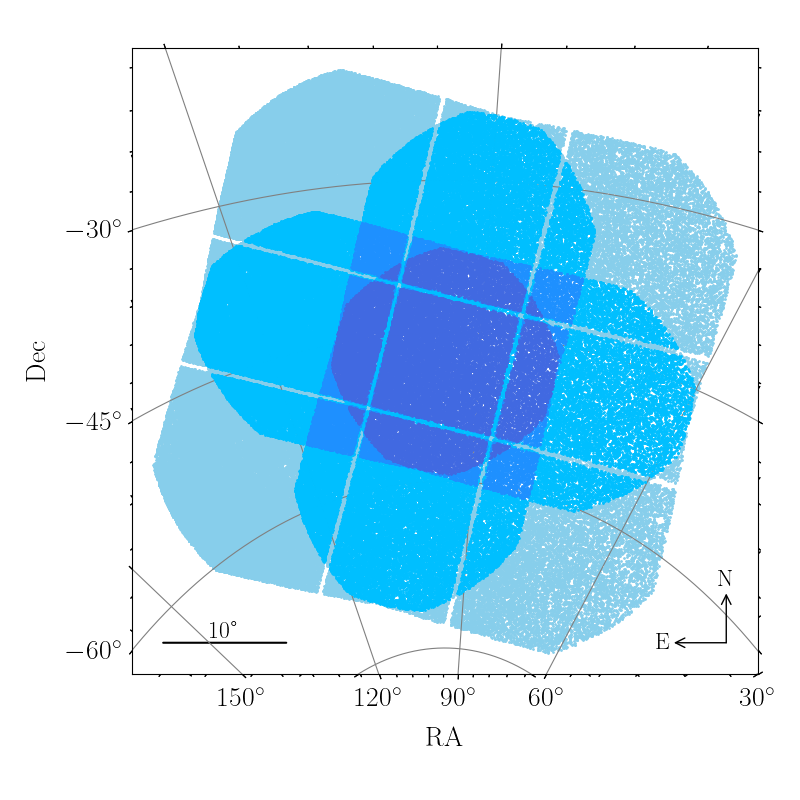

In [24]:
# Plot catalogue in sky
fig, ax = pt.plotPlatoFOV('LOPS2', showGroups=False, ncamStars=dx, fovSize=32, fs=20, ms=2, figsize=(8,8))

---

The following OTYPE names are used:

- Blue supergiants: `BlueSG`
- Asymptotic Giant Branch (AGB) stars: `AGB*`
- Post Asymptotic Giant Branch (post-AGB) stars: `post-AGB*`
- Contact/interacting binaries, spectral types O and B: ``
- Algol-type binaries: `Al*`

Reference: `https://simbad.cds.unistra.fr/Pages/guide/otypes.htx`

### Pre-MS stars (Konstanze)

In [72]:
df_pMS = pd.read_csv(path / 'table_preMS_LOPS2.csv')
df_pMS['Gaia DR3 ID'] = df_pMS['Gaia DR3 ID'].astype(str)

In [73]:
# Cross-match with all LOPS-FCAM stars
ds_pMS = df_pMS[df_pMS['Gaia DR3 ID'].isin(df['gaiaDR3'])].sort_values(by=['Gmag'])
dt_pMS = df[df['gaiaDR3'].isin(df_pMS['Gaia DR3 ID'])].sort_values(by=['Gmag'])
dt_pMS['otype'] = 'pre-MS'
df_pMS.shape[0], dt_pMS.shape[0]

(53, 53)

In [74]:
# Add sources catalogue
dt0 = add_rows(pd.DataFrame(), dt_pMS)

<IPython.core.display.Javascript object>


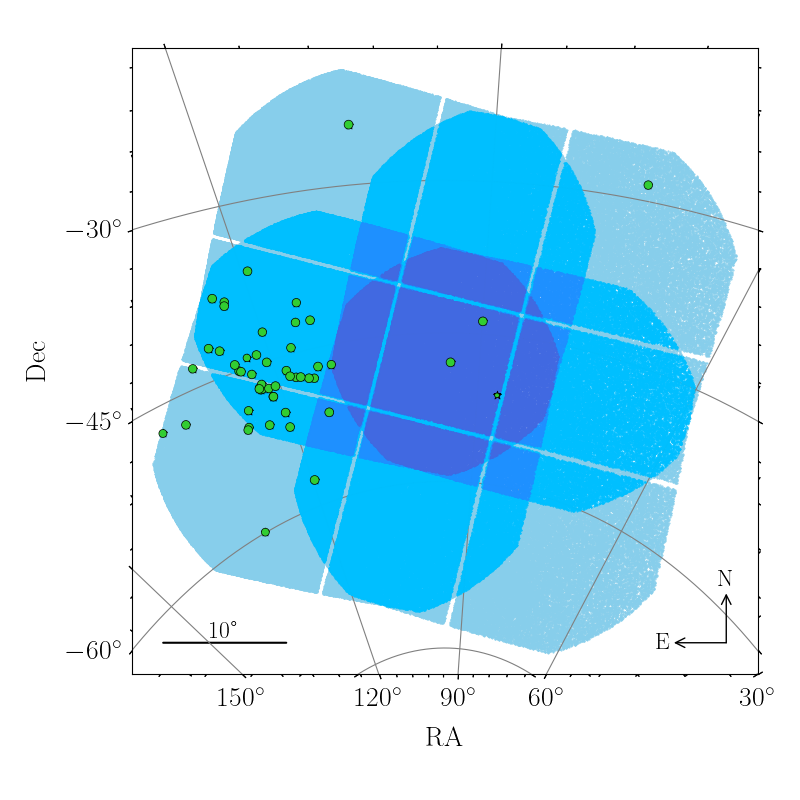

In [46]:
# Show sources in the sky
fig, ax = pt.plotPlatoFOV('LOPS2', showGroups=False, ncamStars=df, fovSize=32, fs=20, ms=1, figsize=(8,8))
ax.scatter(df_pMS.RA, df_pMS.DE, s=40, marker='*', edgecolor='k', facecolor='k',
           linewidth=0.5, transform=ax.get_transform('world'), zorder=10);
ax.scatter(dt_pMS.ra, dt_pMS.dec, s=3*dt_pMS.Gmag, marker='o', edgecolor='k', facecolor='limegreen',
           linewidth=0.5, transform=ax.get_transform('world'), zorder=10);

### Cross-match with EBs (IJspeert+2024)

In [8]:
df_EB = pd.read_csv(path / 'TESS_OBAF_EB_catalogue.csv')
df_EB = df_EB[df_EB.phot_g_mean_mag < 13.5]

In [9]:
# Correct Gaia ID column to float
df_EB.GAIA_DR3 = df_EB.GAIA_DR3.fillna(-1) 
df_EB.GAIA_DR3 = df_EB.GAIA_DR3.astype(float)

# Dummy array to set Gaia ID to float
dx = dt.copy()
dx.gaiaDR3 = dx.gaiaDR3.astype(float)

# Cross-match with Luc's catalogue
# df0_EB = df_EB[df_EB['GAIA_DR3'].isin(dx['gaiaDR3'])].sort_values(by=['GAIA_DR3'])
dt_EB = dx[dx['gaiaDR3'].isin(df_EB['GAIA_DR2'])].sort_values(by=['gaiaDR3'])
dt_EB['otype'] = 'EB*'
dt_EB.shape[0]

4082

In [77]:
# Add sources to catalogue
dt0 = add_rows(dt0, dt_EB)

<IPython.core.display.Javascript object>


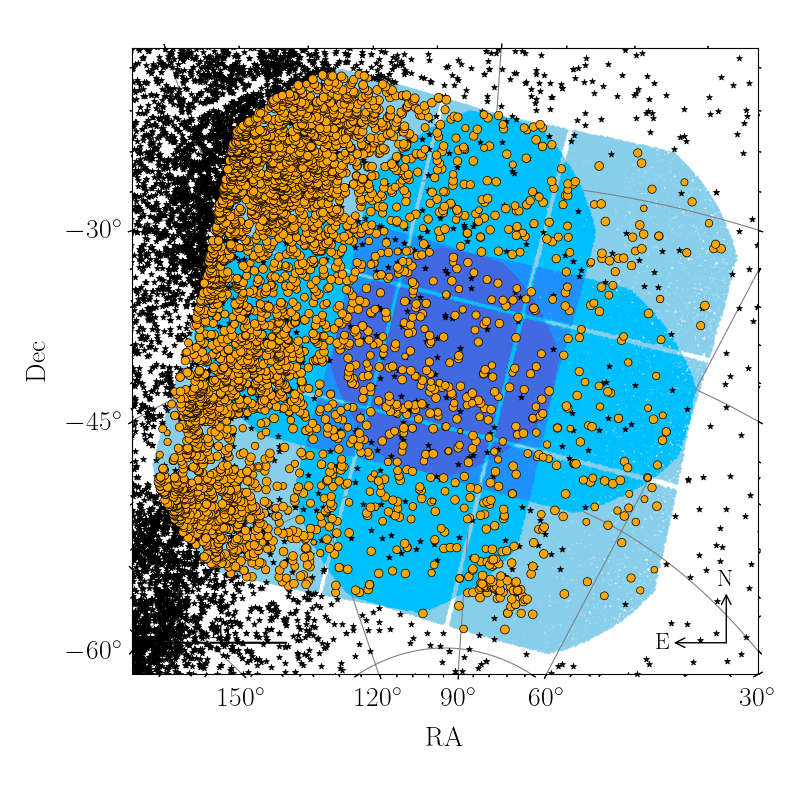

In [10]:
# Show sources in the sky
fig, ax = pt.plotPlatoFOV('LOPS2', showGroups=False, ncamStars=dt, fovSize=32, fs=20, ms=1, figsize=(8,8))
ax.scatter(df_EB.ra, df_EB.dec, s=20, marker='*', edgecolor='k', facecolor='k',
            linewidth=0.5, transform=ax.get_transform('world'), zorder=10);
ax.scatter(dt_EB.ra, dt_EB.dec, s=3*dt_EB.Gmag, marker='o', edgecolor='k', facecolor='orange',
            linewidth=0.5, transform=ax.get_transform('world'), zorder=10);

### Cross-match with binaries (Simbad)

In [34]:
# Select three classes of binaries
dt_binary = dt[(dt.otype == '**')]
dt_SBA    = dt[(dt.otype == 'SB*') & (dt.spec == 'A')]
dt_SBB    = dt[(dt.otype == 'SB*') & (dt.spec == 'B')]
dt_binary.shape[0], dt_SBA.shape[0], dt_SBB.shape[0]

(152, 65, 10)

In [35]:
# Add sources to catalogue
dt0 = add_rows(dt0, dt_binary)
dt0 = add_rows(dt0, dt_SBA)
dt0 = add_rows(dt0, dt_SBB)

<IPython.core.display.Javascript object>


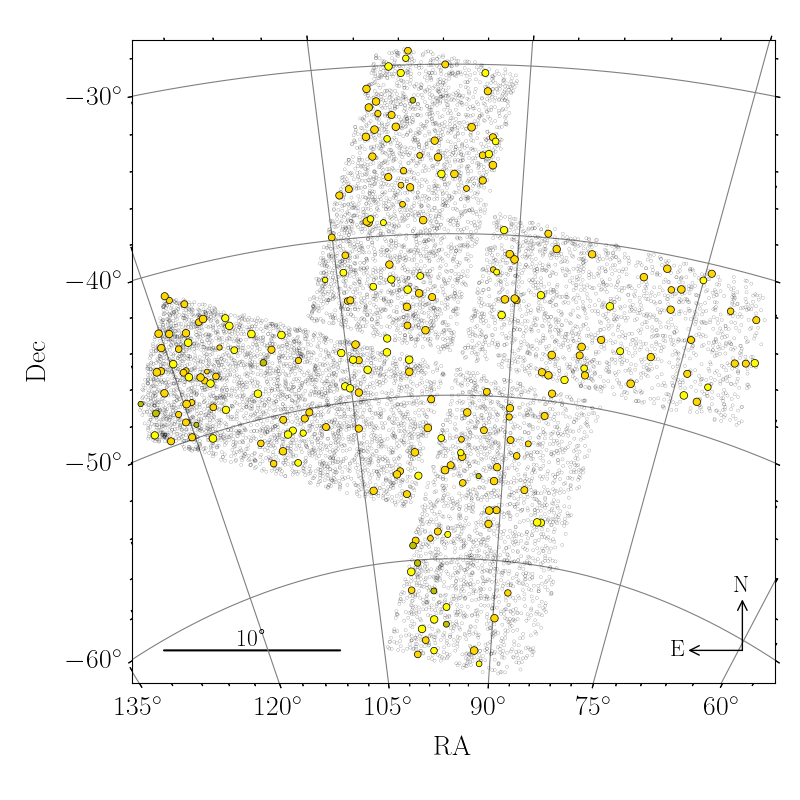

In [36]:
# Show sources in the sky
fig, ax = pt.plotPlatoFOV('LOPS2', raStars=dt.ra, decStars=dt.dec, fovSize=20, figsize=(8,8))
ax.scatter(dt_binary.ra, dt_binary.dec, s=3*dt_binary.Gmag, marker='o', edgecolor='k', facecolor='gold',
           linewidth=0.5, transform=ax.get_transform('world'), zorder=10);
ax.scatter(dt_SBA.ra, dt_SBA.dec, s=3*dt_SBA.Gmag, marker='o', edgecolor='k', facecolor='yellow',
           linewidth=0.5, transform=ax.get_transform('world'), zorder=10);
ax.scatter(dt_SBB.ra, dt_SBB.dec, s=3*dt_SBB.Gmag, marker='o', edgecolor='k', facecolor='y',
           linewidth=0.5, transform=ax.get_transform('world'), zorder=10);

### Other Simbad catalogues

In [37]:
dt_BSG  = dt[dt.otype == 'BlueSG']
dt_AGB  = dz[dz.otype == 'AGB*']
dt_pAGB = dt[dt.otype == 'post-AGB*']
dt_BSG.shape[0], dt_AGB.shape[0], dt_pAGB.shape[0]

(1, 1, 1)

In [38]:
# Add sources to catalogue
dt0 = add_rows(dt0, dt_BSG)
dt0 = add_rows(dt0, dt_AGB)
dt0 = add_rows(dt0, dt_pAGB)

<IPython.core.display.Javascript object>


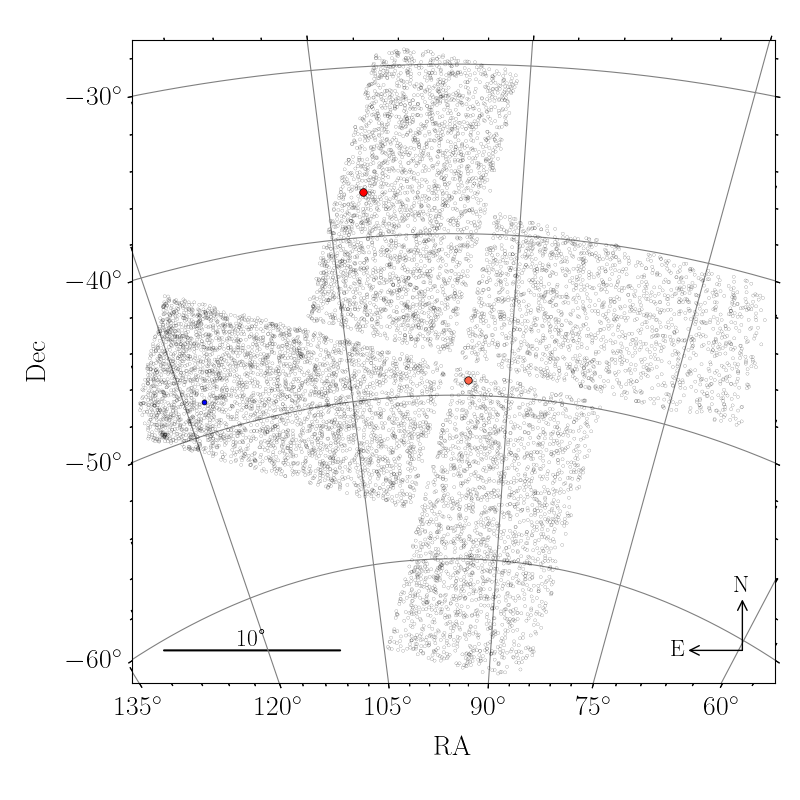

In [39]:
# Show sources in the sky
fig, ax = pt.plotPlatoFOV('LOPS2', raStars=dt.ra, decStars=dt.dec, fovSize=20, figsize=(8,8))
ax.scatter(dt_BSG.ra, dt_BSG.dec, s=3*dt_BSG.Gmag, marker='o', edgecolor='k', facecolor='blue',
           linewidth=0.5, transform=ax.get_transform('world'), zorder=10);
ax.scatter(dt_AGB.ra, dt_AGB.dec, s=3*dt_AGB.Gmag, marker='o', edgecolor='k', facecolor='tomato',
           linewidth=0.5, transform=ax.get_transform('world'), zorder=10);
ax.scatter(dt_pAGB.ra, dt_pAGB.dec, s=3*dt_pAGB.Gmag, marker='o', edgecolor='k', facecolor='red',
           linewidth=0.5, transform=ax.get_transform('world'), zorder=10);

### subdwarf stars (Murat)

All stars of this catalogue is within the LOPS2 N-CAM FOV.

In [106]:
df_sd = pd.read_csv(path / 'table_sd_LOPS2.csv')
df_sd.shape[0]

65

In [91]:
# Fetch Gaia information
dex = df_sd.index
dx = df_sd.copy()
gaia = np.array([dx['GaiaEDR3'].iloc[i] for i in dex]).astype(int) 
ra   = np.array([dx['RA_ICRS'].iloc[i] for i in dex]) 
dec  = np.array([dx['DE_ICRS'].iloc[i] for i in dex])
dx = pd.DataFrame({'gaiaDR3': gaia, 'ra': ra, 'dec': dec})
dt_sd = fetch_gaia_info(dx)
dt_sd['otype'] = 'sd'

In [92]:
# Add sources to catalogue
dt0 = add_rows(dt0, dt_sd)

<IPython.core.display.Javascript object>


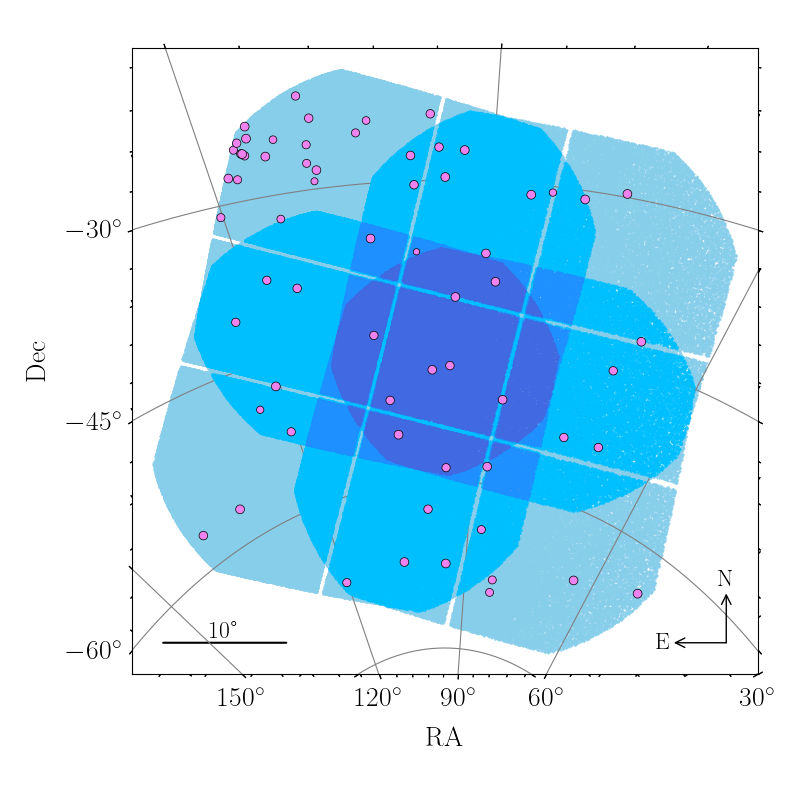

In [93]:
# Show sources in the sky
fig, ax = pt.plotPlatoFOV('LOPS2', showGroups=False, ncamStars=dt, fovSize=32, fs=20, ms=1, figsize=(8,8))
ax.scatter(dt_sd.ra, dt_sd.dec, s=3*dt_sd.Gmag, marker='o', edgecolor='k', facecolor='violet',
            linewidth=0.5, transform=ax.get_transform('world'), zorder=10);

### WD stars (Murat)

All stars of this catalogue is within the LOPS2 N-CAM FOV.

In [96]:
df_WD  = pd.read_csv(path / 'table_wd_LOPS2.csv')
df_WD.shape[0]

20

In [97]:
# Fetch Gaia information
dex = df_WD.index
dx = pd.DataFrame({
    'gaiaDR3': np.array([df_WD.iloc[i].GaiaEDR3 for i in dex]).astype(np.int64), 
    'ra': np.array([df_WD.iloc[i].RA_ICRS for i in dex]), 
    'dec': np.array([df_WD.iloc[i].DE_ICRS for i in dex]),
})
dt_WD = fetch_gaia_info(dx)
dt_WD['otype'] = 'WD'

In [99]:
# dt_WD

In [46]:
# Add sources to catalogue
dt0 = add_rows(dt0, dt_WD)

<IPython.core.display.Javascript object>


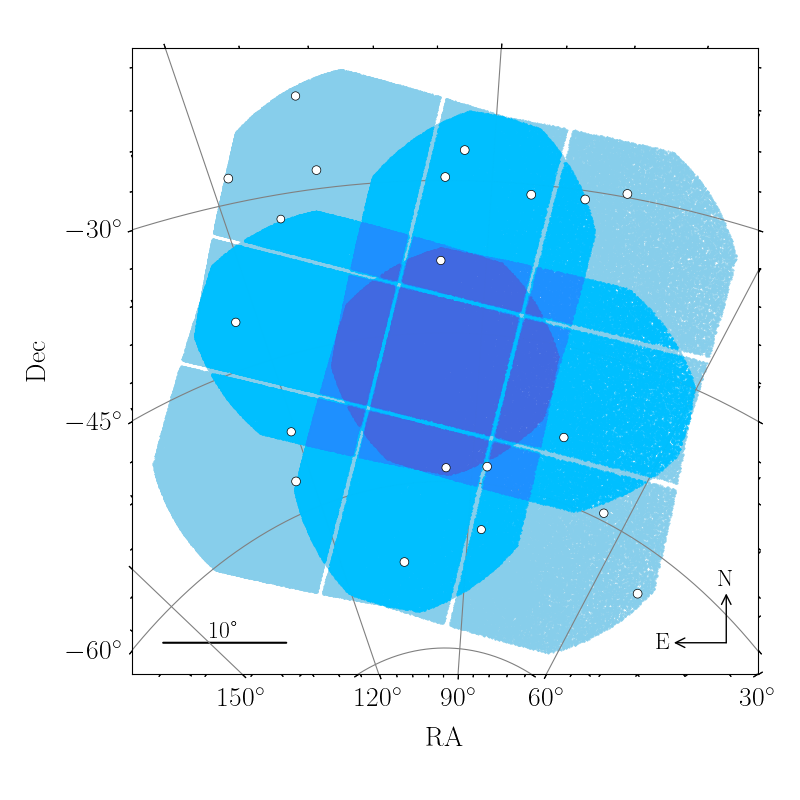

In [100]:
# Show sources in the sky
fig, ax = pt.plotPlatoFOV('LOPS2', ncamStars=dt, fovSize=32, fs=20, ms=1, figsize=(8,8))
ax.scatter(dt_WD.ra, dt_WD.dec, s=3*dt_WD.Gmag, marker='o', edgecolor='k', facecolor='w',
            linewidth=0.5, transform=ax.get_transform('world'), zorder=10);

### Plot star in sky

In [101]:
dx = dt0.copy().reset_index(drop=True)
dx.shape[0]

404

In [102]:
dx.gaiaDR3 = dx.gaiaDR3.astype(int)
dx.to_feather(path / 'scvPIC_NCAM.ftr')

In [103]:
dx.gaiaDR3 = dx.gaiaDR3.astype(np.int64).astype(str)
dx.to_csv(path / 'scvPIC_NCAM.txt', index=False)

<IPython.core.display.Javascript object>


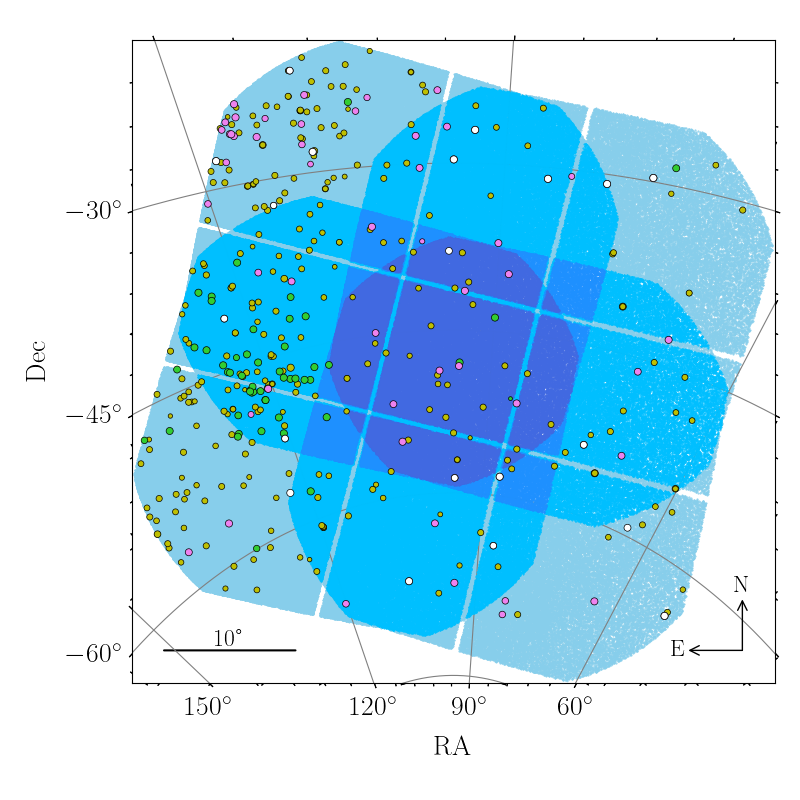

In [105]:
# Show pointign field
zorder, s, fov = 10, 2, 30
fig, ax = pt.plotPlatoFOV('LOPS2', ncamStars=dt, fovSize=30, fs=20, ms=1, figsize=(8,8))


# ax.scatter(dt_binary.ra, dt_binary.dec, s=s*dt_binary.Gmag, marker='o', edgecolor='k', facecolor='orange',
#            linewidth=0.5, transform=ax.get_transform('world'), zorder=zorder)
# ax.scatter(dt_SBA.ra, dt_SBA.dec, s=s*dt_SBA.Gmag, marker='o', edgecolor='k', facecolor='gold',
#            linewidth=0.5, transform=ax.get_transform('world'), zorder=zorder)
# ax.scatter(dt_SBB.ra, dt_SBB.dec, s=s*dt_SBB.Gmag, marker='o', edgecolor='k', facecolor='yellow',
#            linewidth=0.5, transform=ax.get_transform('world'), zorder=zorder)

ax.scatter(dt_EB.ra, dt_EB.dec, s=s*dt_EB.Gmag, marker='o', edgecolor='k', facecolor='y',
           linewidth=0.5, transform=ax.get_transform('world'), zorder=zorder)

ax.scatter(dt_pMS.ra, dt_pMS.dec, s=s*dt_pMS.Gmag, marker='o', edgecolor='k', facecolor='limegreen', 
           linewidth=0.5, transform=ax.get_transform('world'), zorder=zorder)

ax.scatter(dt_sd.ra, dt_sd.dec, s=s*dt_sd.Gmag, marker='o', edgecolor='k', facecolor='violet', 
           linewidth=0.5, transform=ax.get_transform('world'), zorder=zorder)

ax.scatter(dt_WD.ra, dt_WD.dec, s=s*dt_WD.Gmag, marker='o', edgecolor='k', facecolor='w', 
           linewidth=0.5, transform=ax.get_transform('world'), zorder=zorder)

# ax.scatter(dt_BSG.ra.values, dt_BSG.dec.values, s=s*dt_BSG.Gmag.values, marker='o', edgecolor='k', facecolor='royalblue', 
#            linewidth=0.5, transform=ax.get_transform('world'), zorder=zorder)
# ax.scatter(dt_AGB.ra.values, dt_AGB.dec.values, s=dt_AGB.Gmag.values, marker='o', edgecolor='w', facecolor='deeppink', 
#            linewidth=0.5, transform=ax.get_transform('world'), zorder=zorder)
# ax.scatter(dt_pAGB.ra.values, dt_pAGB.dec.values, s=dt_pAGB.Gmag.values, marker='o', edgecolor='k', facecolor='tomato', 
#            linewidth=0.5, transform=ax.get_transform('world'), zorder=zorder)

fig.savefig(path / 'starcat_GaiaDR3_NCAM_LOPS2.png', bbox_inches='tight', dpi=300);

<IPython.core.display.Javascript object>


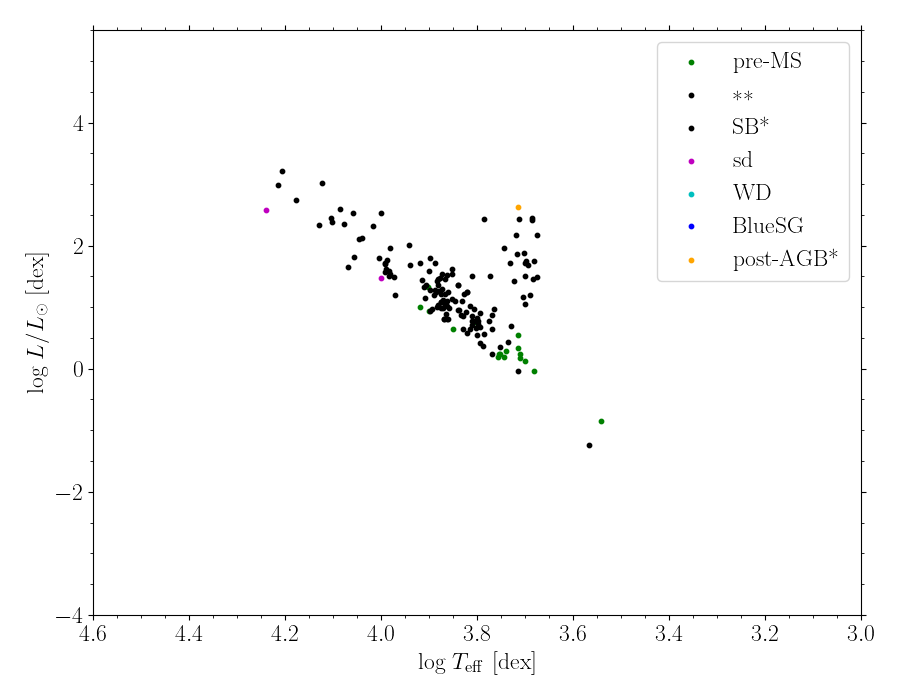

In [58]:
fig, ax = plt.subplots(1, 1, figsize=(9,7))
colors = ['g', 'k', 'k', 'm', 'c', 'b', 'orange']
otypes = ['pre-MS', '**', 'SB*', 'sd', 'WD', 'BlueSG', 'post-AGB*']
for color, otype in zip(colors, otypes):
    dx = dt0[dt0.otype == otype]
    ax.scatter(np.log10(dx.Teff), np.log10(dx.Lum), c=color, s=10, cmap="rainbow", label=otype)
ax.set_xlabel(r'log $T_{\rm eff}$ [dex]')
ax.set_ylabel(r'log $L/L_{\odot}$ [dex]')
ax.invert_xaxis()
ax.set_xlim(4.6, 3.0)
ax.set_ylim(-4.0, 5.5)
ax.legend()
plt.tight_layout()
fig.savefig(path / 'HRD_NCAM_LOPS2.png', bbox_inches='tight', dpi=300);